HISTROGRAMA DE UNA IMAGEN CONTRASTADA

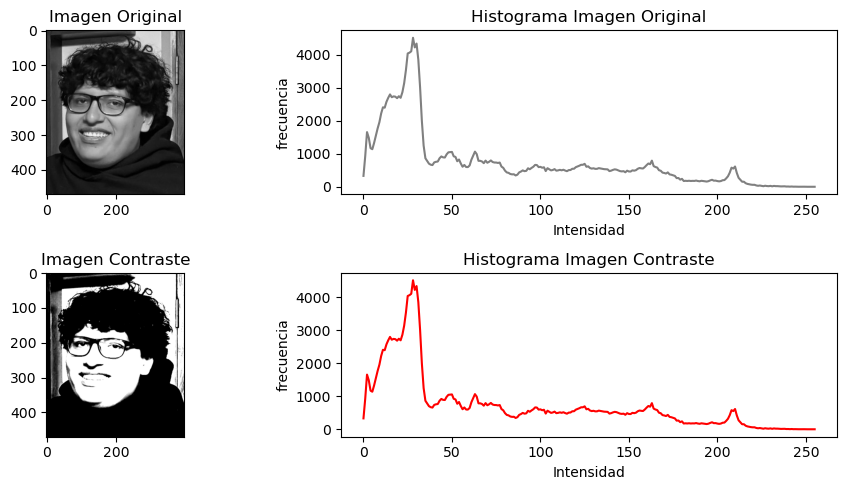

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# recibimos imagen en escala de grises
def contraste(img, factor=1.0):
    img = img.astype(np.float32)
    media = np.mean(img)
    img_contraste = media + (img-media)*factor
    img_contraste = np.clip(img_contraste, 0, 255).astype(np.uint8)
    return img_contraste

imagen = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
contrastesito = 7
imagen_contraste = contraste(imagen, contrastesito)

# Calculo de Histograma
histograma_ori = cv2.calcHist([imagen], [0], None, [256], [0, 256])
histograma_new = cv2.calcHist([imagen_contraste], [0], None, [256], [0, 256])

# PLOTEAR
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')

plt.subplot(2,2,2)
plt.plot(histograma_ori, color='gray')
plt.xlabel('Intensidad')
plt.ylabel('frecuencia')
plt.title('Histograma Imagen Original')

plt.subplot(2,2,3)
plt.imshow(imagen_contraste, cmap='gray')
plt.title('Imagen Contraste')

plt.subplot(2,2,4)
plt.plot(histograma_ori, color='red')
plt.xlabel('Intensidad')
plt.ylabel('frecuencia')
plt.title('Histograma Imagen Contraste')

plt.tight_layout()
plt.show()

CALCULAR EL HISTOGRAMA DE UN PUNTO DE INTERES DE UNA IMAGEN A COLORES

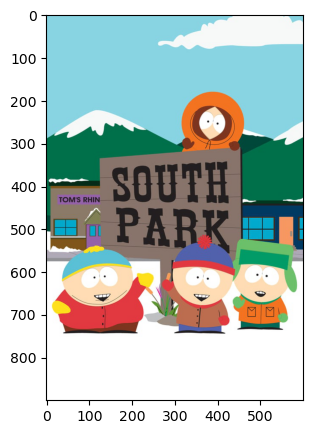

Dimensiones de la imagen: (900, 600, 3)
Coordenadas de corte: y=[180:300], x=[350:450]


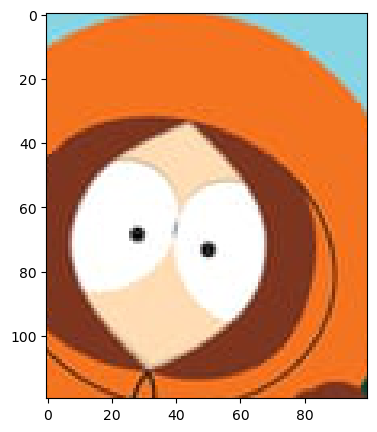

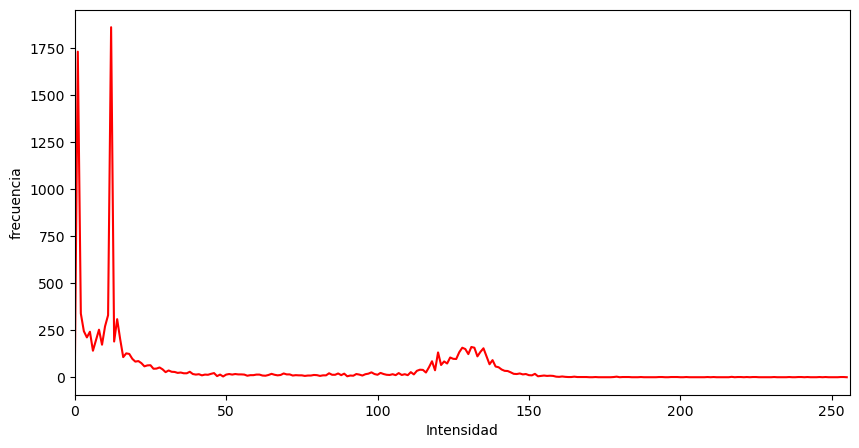

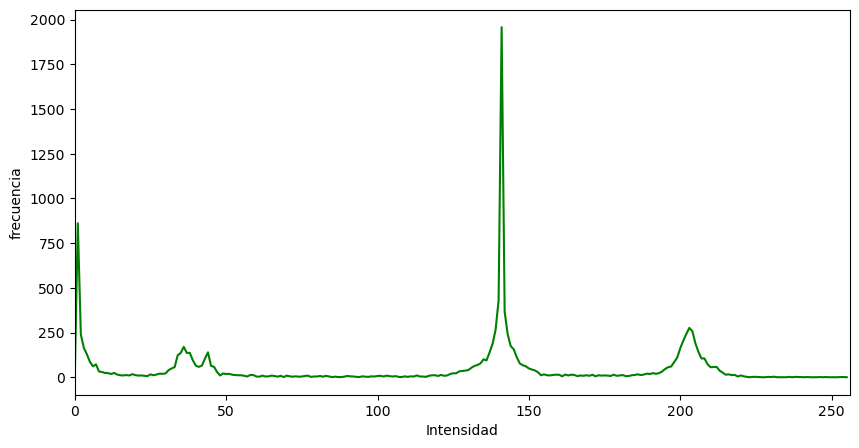

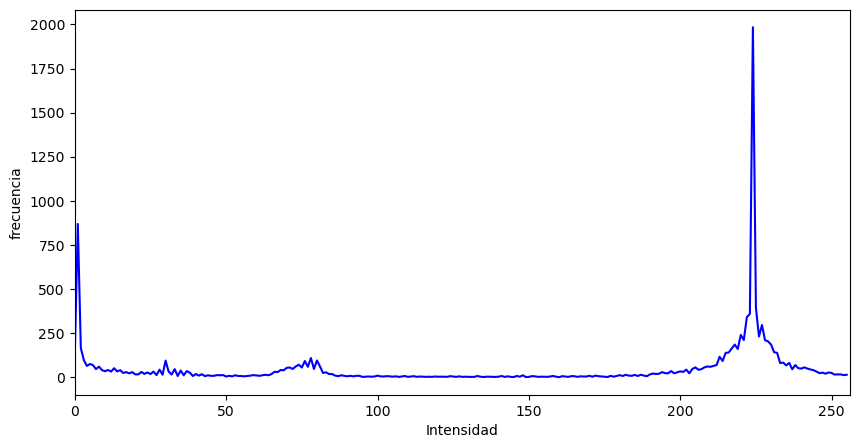

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

imagen_bgr = cv2.imread('southpark.jpg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

plt.rcParams['figure.figsize'] = [10,5]
plt.imshow(imagen_rgb)
plt.show()

# Verificar las dimensiones de la imagen
alto, ancho, canales = imagen_rgb.shape
print(f"Dimensiones de la imagen: {imagen_rgb.shape}")

# Corte más pequeño y más a la derecha
y1, y2 = 180, min(300, alto)  # Más pequeño: solo 100px de alto
x1, x2 = 350, min(450, ancho)  # Más a la derecha: empieza en x=400
 
print(f"Coordenadas de corte: y=[{y1}:{y2}], x=[{x1}:{x2}]")

# Verificar que el corte no esté vacío
if y2 > y1 and x2 > x1:
    plt.imshow(imagen_rgb[y1:y2, x1:x2, :])
    plt.show()
    
    imagen_cortada = imagen_rgb[y1:y2, x1:x2, :]
    
    # Crear directorio si no existe
    os.makedirs('histogramas', exist_ok=True)
    
    plt.imsave('histogramas/imagen_cortada.jpg', imagen_cortada)
    
    imagen_final = plt.imread('histogramas/imagen_cortada.jpg')
    color = ('r', 'g', 'b')
    
    # Impresion de histograma por canales
    for canal, col in enumerate(color):
        histograma = cv2.calcHist([imagen_final*255], [canal], None, [256], [0,256])
        plt.plot(histograma, color=col)
        plt.xlabel('Intensidad')
        plt.ylabel('frecuencia')
        plt.xlim([0,256])
        plt.show()

ECUALIZACION DE UN HISTOGRAMA "SE DESEA NORMALIZAR UNA IMAGEN A UN PUNTO OPTIMO POR HISTOGRAMA"

C:\Users\NITRO V 15\AppData\Local\Temp\ipykernel_11404\213119985.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(imagen_bgr.flatten(), 256, [0, 256], color='r') # histograma original


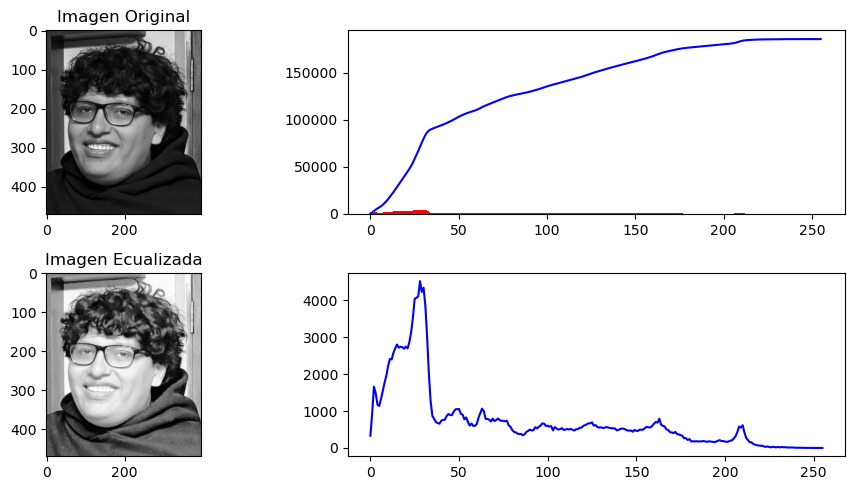

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
histograma, calculo = np.histogram(imagen_bgr.flatten(), 256, [0, 256])
distAcum = histograma.cumsum()
dis_norm = distAcum * histograma.max() / distAcum.max()
ecualizar = cv2.equalizeHist(imagen_bgr)
histograma_equ, _ = np.histogram(ecualizar.flatten(), 256, [0, 256])

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.title('Imagen Original')
plt.imshow(imagen_bgr, cmap='gray')

plt.subplot(2,2,2)
plt.plot(distAcum, color='b')
# imprimir histograma por plt
plt.hist(imagen_bgr.flatten(), 256, [0, 256], color='r') # histograma original

plt.subplot(2,2,3)
plt.title('Imagen Ecualizada')
plt.imshow(ecualizar, cmap='gray')

plt.subplot(2,2,4)
plt.plot(histograma, color='b') # histograma ecualizado

plt.tight_layout()
plt.show()

ECUALIZACION DE HISTOGRAMA A COLORES

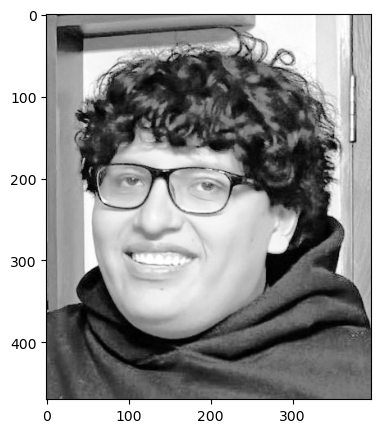

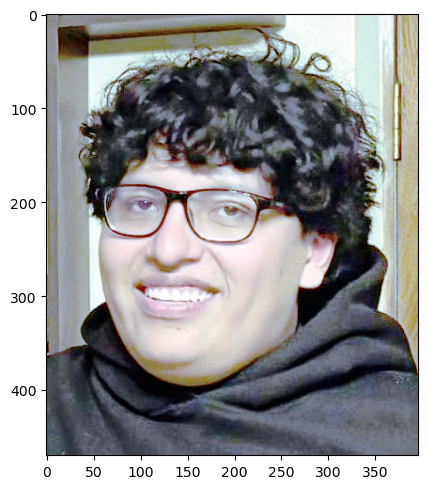

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# MEJORAR
imagen_bgr = cv2.imread('PDI2026/Clase1/chanki.jpg')
imagen_gray = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
ecualizada = cv2.equalizeHist(imagen_gray)
ecu_color = cv2.merge([cv2.equalizeHist(imagen_bgr[:,:,0]), cv2.equalizeHist(imagen_bgr[:,:,1]), cv2.equalizeHist(imagen_bgr[:,:,2])])
plt.imshow(ecualizada, cmap='gray')
plt.show()

plt.imshow(cv2.cvtColor(ecu_color, cv2.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()

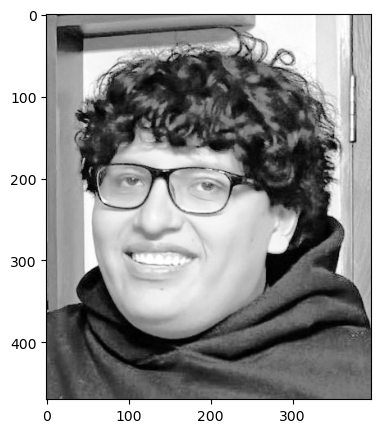

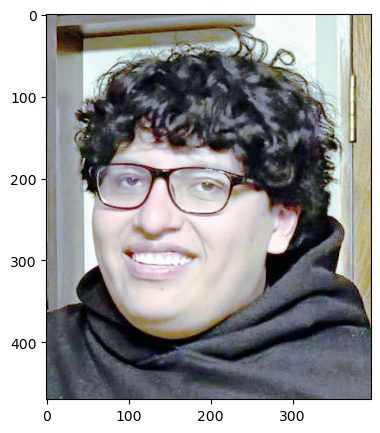

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('PDI2026/Clase1/chanki.jpg')

b, g, r = cv2.split(imagen_bgr)

b_eq = cv2.equalizeHist(b)
g_eq = cv2.equalizeHist(g)
r_eq = cv2.equalizeHist(r)

ecu_color = cv2.merge((b_eq, g_eq, r_eq))

plt.figure(figsize=(10,5))

plt.imshow(ecualizada, cmap='gray')
plt.show()

plt.imshow(cv2.cvtColor(ecu_color, cv2.COLOR_BGR2RGB))
plt.show()

ECUALIZACION BASADA EN CLAHE

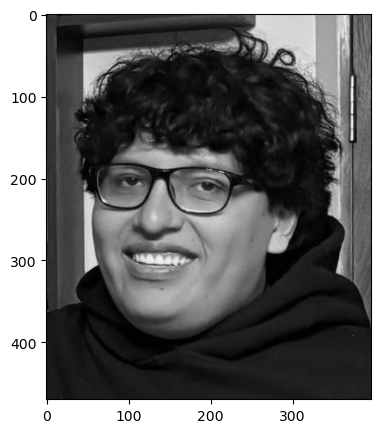

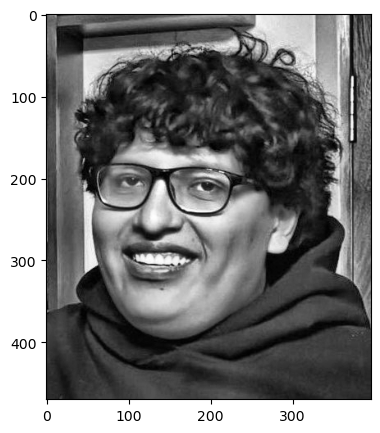

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
clip = 2.0
tiles = 8
clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tiles, tiles))
ecualizado = clahe.apply(imagen_bgr)
plt.imshow(imagen_bgr, cmap = 'gray')
plt.show()
plt.imshow(ecualizado, cmap='gray')
plt.show()

TRANSFORMADA DE FOURIER

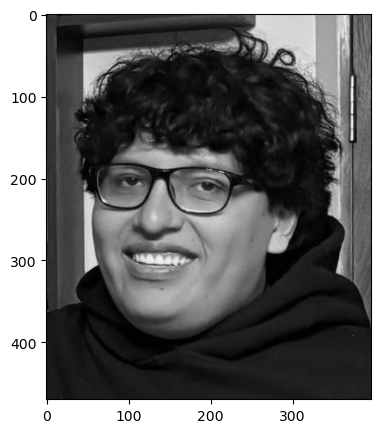

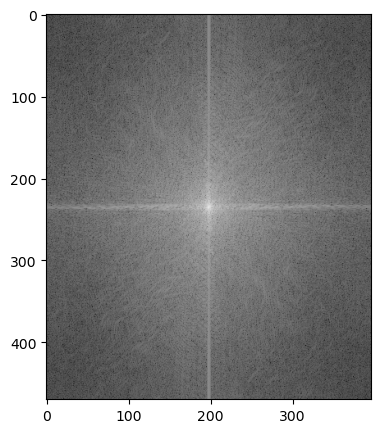

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('PDI2026/Clase1/chanki.jpg', 0)
transformada = np.fft.fft2(imagen_bgr) # transformada inversa
desplazamiento = np.fft.fftshift(transformada) # transformada de fourier
maginitud_espectro = np.log(1 + np.abs(desplazamiento))

plt.imshow(imagen_bgr, cmap='gray')
plt.show()

plt.imshow(maginitud_espectro, cmap='gray')
plt.show()